In [1]:
import torch
import torchvision
import numpy as np

import os
import gc
from torchvision.io import read_video



from transformers import AutoImageProcessor, AutoModel


KeyboardInterrupt: 

In [2]:
#!wget https://www.dropbox.com/s/8scxzzao1d55j7q/clipped_database.zip?dl=0 -O /data/scratch/hmz574/clipped_database.zip

In [3]:
#!mkdir /data/scratch/hmz574/clipped_database
#!mv /data/scratch/hmz574/clipped_database.zip /data/scratch/hmz574/clipped_database/
#!unzip /data/scratch/hmz574/clipped_database/clipped_database.zip -d /data/scratch/hmz574/clipped_database/

In [4]:
#!mkdir /data/scratch/hmz574/clipped_database/encoded

In [5]:
def video_loader(video_path):
    frames, _, _ = read_video(str(video_path), output_format="TCHW")
    return frames


In [6]:
dataset_path = '/data/scratch/hmz574/clipped_database/clipped_database/video/'
output_path = '/data/scratch/hmz574/clipped_database/encoded/'
file_list = os.listdir(dataset_path)
print(len(file_list))

1763


In [7]:
#os.environ['HF_HOME'] = '/data/scratch/hhy696/hf_home/'

In [8]:
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small')
model = AutoModel.from_pretrained('facebook/dinov2-small')

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [9]:
#pooled_features = []
#pooled_names = []

In [10]:
i = 0
for file_name in file_list:
    gc.collect()
    print(file_name)
    v = video_loader(dataset_path+file_name)
    if v.shape[0] > 30: # crop any greater than 1 seconds
        v = v[0:30]
    gc.collect()
    inputs = processor(images=v, return_tensors="pt")
    outputs = model(**inputs)
    last_hidden_state = outputs['last_hidden_state']
    cls_token = last_hidden_state[:,0]
    torch.save(cls_token, output_path+file_name+'.pt')

    #pooled = cls_token.mean(0)
    #pooled_features.append(pooled)
    #pooled_names.append(file_name)
    gc.collect()
    i += 1
    if i % 100 == 0:
        print(i)


video13_rest_118.mpg


/data/home/hmz574/.conda/envs/pytorch/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:5: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/data/home/hmz574/.conda/envs/pytorch/lib/python3.12/site-packages/torchvision/io/video.py:199: UserWarning: The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.
  warnings.warn("The pts_unit 'pts' gives wrong results. Please use pts_unit 'sec'.")


video4_rest_120.mpg
video4_groom_257.mpg
videoB_groom_644.mpg
videoB_groom_707.mpg
video4_walk_056.mpg
videoB_rest_213.mpg
video13_groom_085.mpg
video5_rest_024.mpg
videoB_groom_402.mpg
video4_groom_076.mpg
videoB_rest_086.mpg
videoB_rest_063.mpg
videoB_groom_756.mpg
video4_eat_275.mpg
videoB_hang_628.mpg
video4_eat_047.mpg
video13_rest_008.mpg
videoB_rest_262.mpg
video13_rest_001.mpg
video13_groom_080.mpg
video8_rest_034.mpg
videoB_eat_681.mpg
videoB_rest_291.mpg
video4_rest_324.mpg
videoB_rest_168.mpg
video4_groom_194.mpg
video12_eat_114.mpg
video5_groom_182.mpg
video5_eat_124.mpg
videoB_rest_162.mpg
video13_rest_117.mpg
video13_groom_065.mpg
video4_rest_125.mpg
video12_drink_106.mpg
video4_rest_296.mpg
video12_groom_179.mpg
videoB_groom_446.mpg
video7_walk_042.mpg
video6_groom_090.mpg
videoB_rest_004.mpg
videoB_groom_452.mpg
videoB_groom_786.mpg
videoB_rest_128.mpg
video8_rest_022.mpg
video5_rest_053.mpg
video12_eat_166.mpg
video12_walk_103.mpg
video4_eat_044.mpg
videoB_rest_202.mpg

In [11]:
processed_files = os.listdir(output_path)

In [12]:
pooled_features = []
pooled_names = []
i=0
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name)
    data = data.mean(0)
    pooled_features.append(data.detach().numpy())
    i += 1
    if i % 100 == 0:
        print(i)


100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700


In [13]:
pooled_array = np.array(pooled_features)
pooled_array.shape

(1763, 384)

In [14]:
from sklearn.decomposition import PCA
import seaborn as sns

ModuleNotFoundError: No module named 'seaborn'

In [15]:
pca = PCA(n_components=8)
pca_features = pca.fit_transform(pooled_array)

In [16]:
classes = []
for name in pooled_names:
    classes.append(name.split('_')[1])

<Axes: >

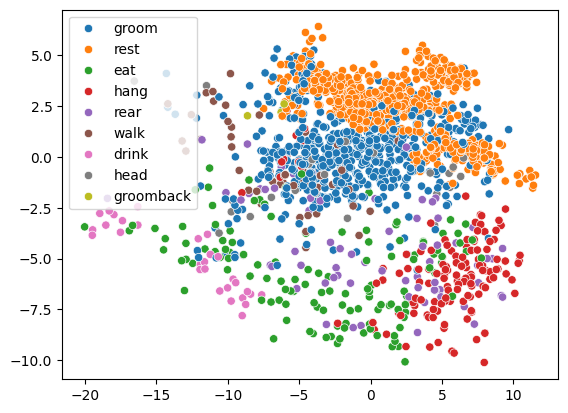

In [106]:
sns.scatterplot(x = pca_features[:,1],y = pca_features[:,2], hue = classes)

In [107]:
import umap
from sklearn.preprocessing import StandardScaler

In [108]:
reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(pca_features)
embedding = reducer.fit_transform(scaled_features)
embedding.shape

/data/home/hhy696/pytorchcpu/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(1763, 2)

<Axes: >

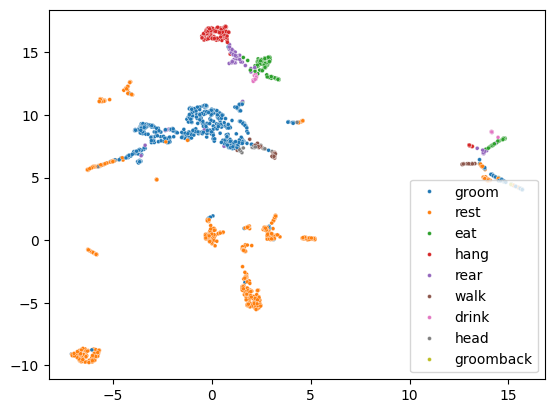

In [109]:
sns.scatterplot(x = embedding[:,0],y = embedding[:,1], hue = classes, s=8)